# PCB Dataset Normalization

Notebook này chuẩn hóa các dataset PCB object detection về cùng một hệ nhãn, đồng thời trực quan hóa rõ sự thay đổi trước và sau chuẩn hóa.

Mục tiêu:
- Khảo sát riêng từng dataset.
- So sánh trước và sau chuẩn hóa cho ảnh, file nhãn, bounding box.
- So sánh phân bố class trước và sau chuẩn hóa.
- Xuất dataset đã chuẩn hóa sang `data/processed/`.

## 1. Imports và cấu hình hiển thị

In [1]:
import os
import shutil
from pathlib import Path
from collections import Counter, defaultdict

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titleweight": "bold",
})

DATASET_COLORS = {
    "DeepPCB": "#4C72B0",
    "HRIPCB": "#DD8452",
    "DsPCBSD+": "#55A868",
}

SPLIT_COLORS = {
    "train": "#4C72B0",
    "valid": "#DD8452",
    "val": "#DD8452",
    "test": "#55A868",
}

DEFECT_COLORS = {
    "open": "#E74C3C",
    "short": "#3498DB",
    "mousebite": "#2ECC71",
    "spur": "#F39C12",
    "copper": "#9B59B6",
    "missing_hole": "#1ABC9C",
    "unknown": "#95A5A6",
}

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## 2. Cấu hình dataset

In [2]:
RAW_ROOT = Path("../data/raw")
PROCESSED_ROOT = Path("../data/processed")

DATASETS = {
    "DeepPCB": {
        "root": RAW_ROOT / "DeepPCB",
        "mapping": {
            0: "copper",
            1: "mousebite",
            2: "open",
            3: "missing_hole",
            4: "short",
            5: "spur",
        },
    },
    "HRIPCB": {
        "root": RAW_ROOT / "HRIPCB",
        "mapping": {
            0: "missing_hole",
            1: "mousebite",
            2: "open",
            3: "short",
            4: "spur",
            5: "copper",
        },
    },
    "DsPCBSD+": {
        "root": RAW_ROOT / "DsPCBSD+",
        "mapping": {
            0: None,
            1: None,
            2: None,
            3: "missing_hole",
            4: "mousebite",
            5: "open",
            6: "copper",
            7: "short",
            8: "spur",
        },
    },
}

FINAL_CLASSES = {
    "open": 0,
    "short": 1,
    "mousebite": 2,
    "spur": 3,
    "copper": 4,
    "missing_hole": 5,
}
FINAL_CLASS_NAMES = list(FINAL_CLASSES.keys())

SPLIT_ALIASES = {
    "val": "valid",
}
SPLIT_ORDER = ["train", "valid", "test"]
IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

print("RAW_ROOT:", RAW_ROOT.resolve())
print("PROCESSED_ROOT:", PROCESSED_ROOT.resolve())

RAW_ROOT: D:\pcb-defect-detection\data\raw
PROCESSED_ROOT: D:\pcb-defect-detection\data\processed


## 3. Các hàm tiện ích

In [ ]:
def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)

def canonical_split_name(split: str) -> str:
    return SPLIT_ALIASES.get(split, split)

def discover_splits(dataset_root: Path):
    splits = []
    for split in ["train", "valid", "val", "test"]:
        images_dir = dataset_root / split / "images"
        labels_dir = dataset_root / split / "labels"
        if images_dir.exists() and labels_dir.exists():
            splits.append(split)
    return splits

def iter_label_files(labels_dir: Path):
    if not labels_dir.exists():
        return
    for entry in os.scandir(labels_dir):
        if entry.is_file() and entry.name.endswith(".txt"):
            yield Path(entry.path)

def read_yolo_label_file(label_path: Path):
    lines = []
    with open(label_path, "r", encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()
            if line:
                lines.append(line)
    return lines

def write_yolo_label_file(label_path: Path, lines):
    ensure_dir(label_path.parent)
    with open(label_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
        if lines:
            f.write("\n")

def find_image_path(images_dir: Path, stem: str):
    for ext in IMAGE_EXTS:
        candidate = images_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None

def safe_copy_image(src: Path, dst: Path):
    ensure_dir(dst.parent)
    shutil.copy2(src, dst)

def parse_box_line(line: str):
    parts = line.split()
    if len(parts) < 5:
        return None
    try:
        class_id = int(float(parts[0]))
        coords = [float(x) for x in parts[1:5]]
        extra = parts[5:] if len(parts) > 5 else []
        return class_id, coords, extra
    except Exception:
        return None

def make_processed_structure(dataset_name: str):
    out_root = PROCESSED_ROOT / dataset_name
    for split in SPLIT_ORDER:
        ensure_dir(out_root / split / "images")
        ensure_dir(out_root / split / "labels")
    return out_root

def make_data_yaml(dataset_name: str, processed_root: Path):
    data_yaml = {
        "path": str(processed_root.resolve()),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "nc": len(FINAL_CLASSES),
        "names": FINAL_CLASS_NAMES,
    }
    with open(processed_root / "data.yaml", "w", encoding="utf-8") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)
    return data_yaml

def load_image(image_path: Path):
    import matplotlib.image as mpimg
    return mpimg.imread(str(image_path))

def draw_yolo_boxes(ax, image, label_lines, title="", id_to_name=None):
    ax.imshow(image)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

    h, w = image.shape[0], image.shape[1]
    for line in label_lines:
        parsed = parse_box_line(line)
        if parsed is None:
            continue
        cls_id, (xc, yc, bw, bh), _ = parsed
        label = id_to_name.get(cls_id, f"id:{cls_id}") if id_to_name is not None else str(cls_id)
        color = DEFECT_COLORS.get(label, DEFECT_COLORS["unknown"])

        x1 = (xc - bw / 2) * w
        y1 = (yc - bh / 2) * h
        bw_px = bw * w
        bh_px = bh * h

        rect = mpatches.Rectangle(
            (x1, y1), bw_px, bh_px,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1, max(0, y1 - 2),
            f" {label} ",
            fontsize=8, color="white",
            va="bottom", ha="left",
            bbox=dict(facecolor=color, edgecolor="none", alpha=0.9, pad=1.2)
        )

FINAL_ID_TO_NAME = {v: k for k, v in FINAL_CLASSES.items()}
RAW_ID_TO_NAME = {
    dataset_name: {k: v for k, v in cfg["mapping"].items() if v is not None}
    for dataset_name, cfg in DATASETS.items()
}

def _annotate_bars(ax):
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f"{int(height):,}",
                (bar.get_x() + bar.get_width() / 2, height),
                ha="center", va="bottom", fontsize=8
            )

def collect_class_counts_by_split(dataset_root: Path, raw_mapping: dict | None = None):
    counts_by_split = {split: Counter() for split in SPLIT_ORDER}

    for split_name in discover_splits(dataset_root):
        split = canonical_split_name(split_name)
        labels_dir = dataset_root / split_name / "labels"
        if not labels_dir.exists():
            continue

        for label_path in iter_label_files(labels_dir):
            for line in read_yolo_label_file(label_path):
                parsed = parse_box_line(line)
                if parsed is None:
                    continue

                class_id = parsed[0]
                if raw_mapping is None:
                    class_name = FINAL_ID_TO_NAME.get(class_id)
                else:
                    class_name = raw_mapping.get(class_id)

                if class_name is None:
                    continue

                counts_by_split[split][class_name] += 1

    return counts_by_split


def _plot_class_counts_by_split(ax, counts_by_split: dict, title: str):
    classes = FINAL_CLASS_NAMES
    x = np.arange(len(classes))
    width = 0.24
    offset_map = {
        split: (idx - (len(SPLIT_ORDER) - 1) / 2) * width
        for idx, split in enumerate(SPLIT_ORDER)
    }

    for split in SPLIT_ORDER:
        values = [counts_by_split.get(split, Counter()).get(cls, 0) for cls in classes]
        bars = ax.bar(
            x + offset_map[split],
            values,
            width=width,
            label=split,
            color=SPLIT_COLORS.get(split, "#888888"),
            edgecolor="white",
            linewidth=0.8,
        )
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.annotate(
                    f"{int(h):,}",
                    (bar.get_x() + bar.get_width() / 2, h),
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    xytext=(0, 2),
                    textcoords="offset points",
                )

    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Số bounding box")
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=25, ha="right")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.legend(title="Split")

## 4. Khảo sát dữ liệu gốc

Mỗi dataset được kiểm tra riêng theo split. Phần này trả về:
- số ảnh
- số file label
- số bounding box
- phân bố class theo nhãn gốc trước khi chuẩn hóa

In [4]:
def inspect_dataset(dataset_name: str, dataset_root: Path, mapping: dict):
    stats = {
        "dataset": dataset_name,
        "root": str(dataset_root),
        "splits": [],
        "totals": {
            "images": 0,
            "labels": 0,
            "boxes": 0,
            "class_counts": Counter(),
            "invalid_lines": 0,
        },
    }

    for split_name in discover_splits(dataset_root):
        split = canonical_split_name(split_name)
        split_root = dataset_root / split_name
        images_dir = split_root / "images"
        labels_dir = split_root / "labels"

        image_count = sum(1 for e in os.scandir(images_dir) if e.is_file()) if images_dir.exists() else 0
        label_files = list(iter_label_files(labels_dir)) if labels_dir.exists() else []

        boxes = 0
        class_counts = Counter()
        invalid_lines = 0

        for label_path in label_files:
            for line in read_yolo_label_file(label_path):
                parsed = parse_box_line(line)
                if parsed is None:
                    invalid_lines += 1
                    continue
                class_id, _, _ = parsed
                boxes += 1
                mapped = mapping.get(class_id, None)
                if mapped is None:
                    class_counts[f"removed_{class_id}"] += 1
                else:
                    class_counts[mapped] += 1

        stats["splits"].append({
            "split": split,
            "images": image_count,
            "labels": len(label_files),
            "boxes": boxes,
            "class_counts": dict(class_counts),
            "invalid_lines": invalid_lines,
        })

        stats["totals"]["images"] += image_count
        stats["totals"]["labels"] += len(label_files)
        stats["totals"]["boxes"] += boxes
        stats["totals"]["class_counts"].update(class_counts)
        stats["totals"]["invalid_lines"] += invalid_lines

    return stats

dataset_inspections = {}
for name, cfg in DATASETS.items():
    if cfg["root"].exists():
        dataset_inspections[name] = inspect_dataset(name, cfg["root"], cfg["mapping"])
    else:
        print(f"[WARN] Missing dataset root: {cfg['root']}")

summary_rows = []
for name, stats in dataset_inspections.items():
    for split_info in stats["splits"]:
        summary_rows.append({
            "dataset": name,
            "split": split_info["split"],
            "images": split_info["images"],
            "labels": split_info["labels"],
            "boxes": split_info["boxes"],
            "invalid_lines": split_info["invalid_lines"],
        })

pre_df = pd.DataFrame(summary_rows)
display(pre_df if not pre_df.empty else pd.DataFrame(columns=["dataset", "split", "images", "labels", "boxes", "invalid_lines"]))

,dataset,split,images,labels,boxes,invalid_lines
0,DeepPCB,train,1050,1050,7166,0
1,DeepPCB,valid,150,150,1003,0
2,DeepPCB,test,300,300,1844,0
3,HRIPCB,train,485,485,2074,0
4,HRIPCB,valid,69,69,298,0
5,HRIPCB,test,139,139,581,0
6,DsPCBSD+,train,7181,7181,14137,0
7,DsPCBSD+,valid,1026,1026,2045,0
8,DsPCBSD+,test,2052,2052,4094,0


## 5. Biểu đồ trước chuẩn hóa theo từng dataset

Mỗi dataset có một biểu đồ riêng. Trong cùng một hình, mỗi metric được chia theo split và so sánh ở cấp độ dataset riêng lẻ.

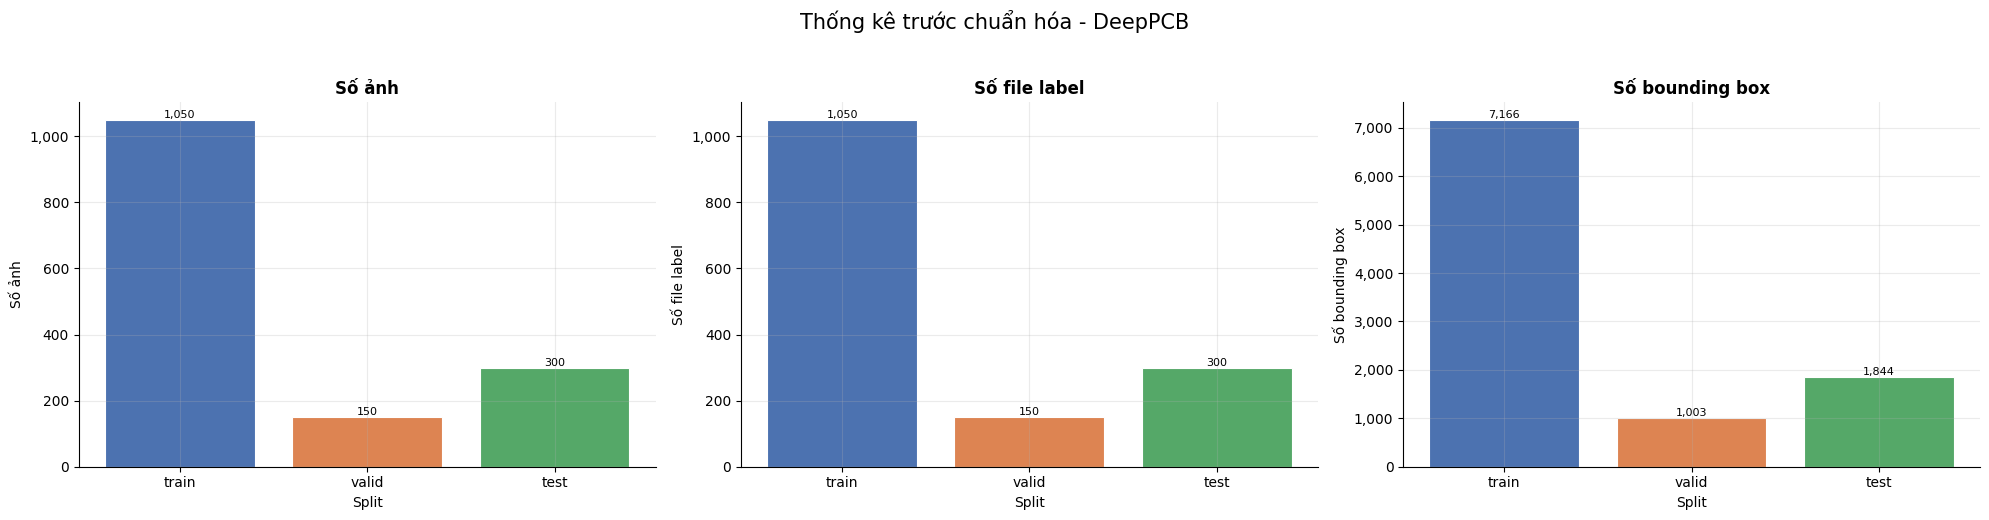

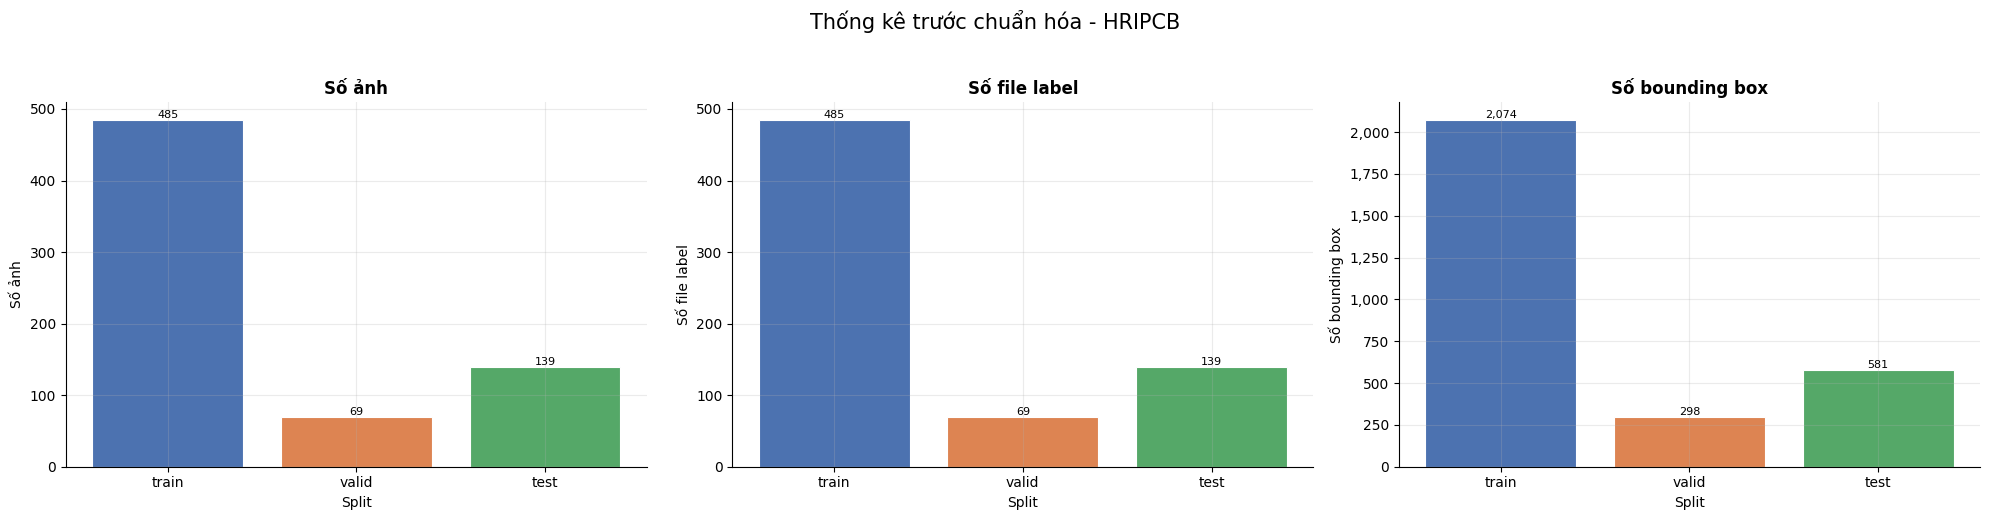

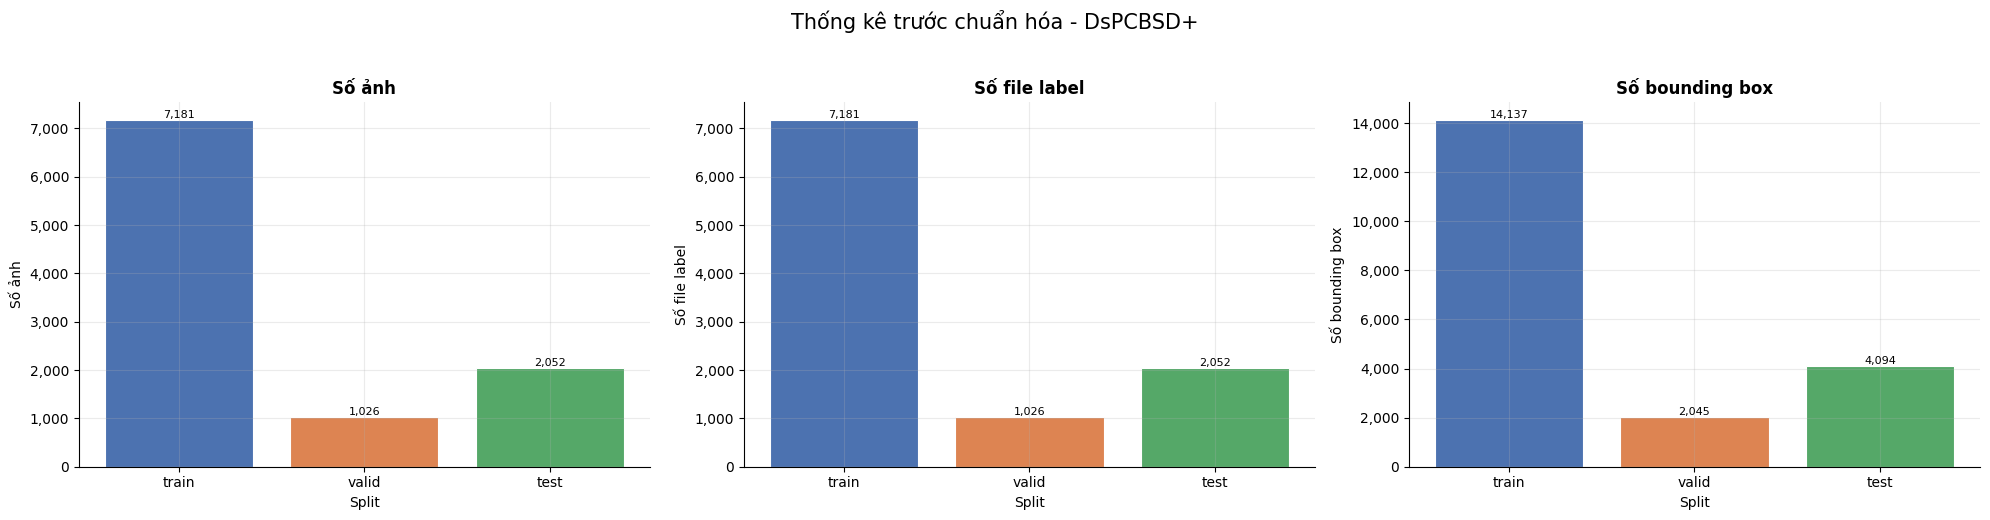

In [5]:
def plot_before_metrics_by_dataset(pre_df: pd.DataFrame):
    if pre_df.empty:
        print("Không có dữ liệu để vẽ.")
        return

    metrics = [
        ("images", "Số ảnh"),
        ("labels", "Số file label"),
        ("boxes", "Số bounding box"),
    ]

    for dataset_name in pre_df["dataset"].unique():
        df = pre_df[pre_df["dataset"] == dataset_name].copy()
        df["split"] = pd.Categorical(df["split"], categories=SPLIT_ORDER, ordered=True)
        df = df.sort_values("split")

        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        fig.suptitle(f"Thống kê trước chuẩn hóa - {dataset_name}", fontsize=15, y=1.03)

        for ax, (metric, title) in zip(axes, metrics):
            pivot = df.pivot_table(index="split", values=metric, aggfunc="sum", observed=False).reindex(SPLIT_ORDER)
            bars = ax.bar(
                pivot.index.astype(str),
                pivot[metric].fillna(0),
                color=[SPLIT_COLORS.get(s, "#888888") for s in pivot.index.astype(str)],
                edgecolor="white", linewidth=0.8
            )
            ax.set_title(title)
            ax.set_xlabel("Split")
            ax.set_ylabel(title)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
            _annotate_bars(ax)

        plt.tight_layout()
        plt.show()

plot_before_metrics_by_dataset(pre_df)

## 6. Biểu đồ class trước chuẩn hóa theo từng dataset

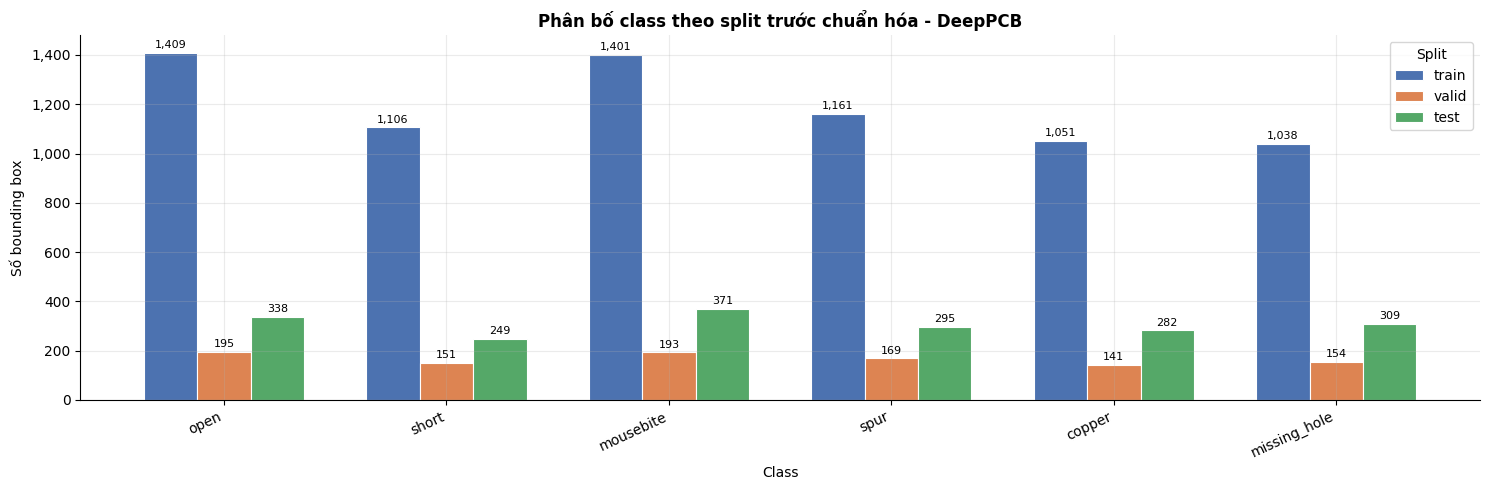

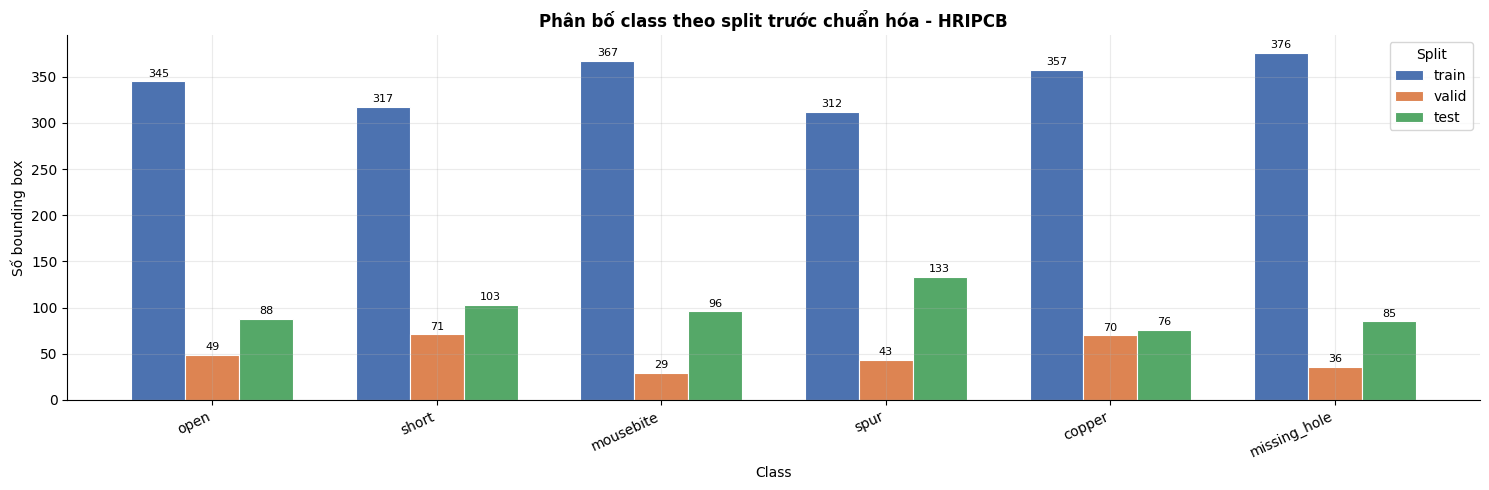

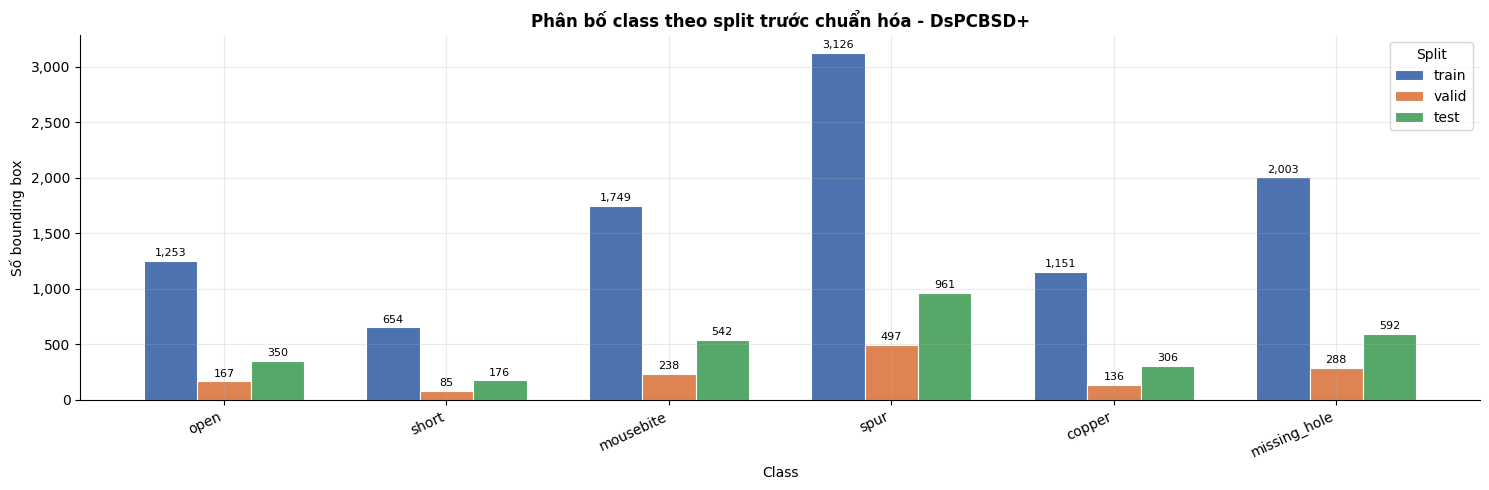

In [6]:
def plot_class_distribution_before(dataset_inspections):
    for dataset_name in dataset_inspections.keys():
        raw_root = DATASETS[dataset_name]["root"]
        raw_mapping = DATASETS[dataset_name]["mapping"]

        counts_by_split = collect_class_counts_by_split(raw_root, raw_mapping)

        fig, ax = plt.subplots(figsize=(15, 5))
        _plot_class_counts_by_split(
            ax,
            counts_by_split,
            f"Phân bố class theo split trước chuẩn hóa - {dataset_name}"
        )
        plt.tight_layout()
        plt.show()

plot_class_distribution_before(dataset_inspections)


## 7. Chuẩn hóa dữ liệu

Quy tắc chuẩn hóa:
- Map class id gốc về 6 class đích.
- Loại bỏ các class không dùng.
- Nếu một ảnh không còn bounding box sau lọc thì xóa ảnh đó khỏi output.
- Xuất dữ liệu sạch sang `data/processed/<dataset_name>/`.

In [7]:
def normalize_dataset(
    dataset_name: str,
    dataset_root: Path,
    mapping: dict,
    remove_empty_images: bool = True,
    copy_images: bool = True,
):
    processed_root = make_processed_structure(dataset_name)

    report = {
        "dataset": dataset_name,
        "root": str(dataset_root),
        "processed_root": str(processed_root),
        "splits": {},
        "before_class_counts": Counter(),
        "after_class_counts": Counter(),
        "removed_boxes": 0,
        "removed_images": 0,
        "invalid_lines": 0,
        "total_label_files": 0,
        "total_images_copied": 0,
    }

    for split_name in discover_splits(dataset_root):
        split = canonical_split_name(split_name)

        src_images_dir = dataset_root / split_name / "images"
        src_labels_dir = dataset_root / split_name / "labels"
        if not src_images_dir.exists() or not src_labels_dir.exists():
            continue

        dst_images_dir = processed_root / split / "images"
        dst_labels_dir = processed_root / split / "labels"
        ensure_dir(dst_images_dir)
        ensure_dir(dst_labels_dir)

        split_label_files = 0
        split_boxes_before = 0
        split_boxes_after = 0
        split_removed_boxes = 0
        split_removed_images = 0
        split_images_copied = 0

        label_files = list(iter_label_files(src_labels_dir))
        for label_path in tqdm(label_files, desc=f"{dataset_name} - {split}", leave=False):
            split_label_files += 1
            report["total_label_files"] += 1

            new_lines = []
            lines = read_yolo_label_file(label_path)

            for line in lines:
                parsed = parse_box_line(line)
                if parsed is None:
                    report["invalid_lines"] += 1
                    continue

                class_id, coords, extra = parsed
                split_boxes_before += 1

                raw_class = mapping.get(class_id, None)
                if raw_class is None:
                    split_removed_boxes += 1
                    report["removed_boxes"] += 1
                    continue

                split_boxes_after += 1
                report["before_class_counts"][raw_class] += 1
                report["after_class_counts"][raw_class] += 1

                final_id = FINAL_CLASSES[raw_class]
                new_line = " ".join([str(final_id)] + [str(x) for x in coords] + [str(x) for x in extra])
                new_lines.append(new_line)

            dst_label_path = dst_labels_dir / label_path.name
            src_image_path = find_image_path(src_images_dir, label_path.stem)

            if len(new_lines) == 0 and remove_empty_images:
                split_removed_images += 1
                report["removed_images"] += 1
                if dst_label_path.exists():
                    dst_label_path.unlink()
                continue

            write_yolo_label_file(dst_label_path, new_lines)

            if src_image_path is not None and copy_images:
                dst_image_path = dst_images_dir / src_image_path.name
                safe_copy_image(src_image_path, dst_image_path)
                split_images_copied += 1
                report["total_images_copied"] += 1

        report["splits"][split] = {
            "label_files_before": split_label_files,
            "label_files_after": split_label_files - split_removed_images,
            "images_before": sum(1 for e in os.scandir(src_images_dir) if e.is_file()),
            "images_after": split_images_copied,
            "boxes_before": split_boxes_before,
            "boxes_after": split_boxes_after,
            "boxes_removed": split_removed_boxes,
            "images_removed": split_removed_images,
            "images_copied": split_images_copied,
        }

    report["data_yaml"] = make_data_yaml(dataset_name, processed_root)
    return report

reports = {}
for name, cfg in DATASETS.items():
    if cfg["root"].exists():
        reports[name] = normalize_dataset(name, cfg["root"], cfg["mapping"], remove_empty_images=True, copy_images=True)
    else:
        print(f"[WARN] Missing dataset root: {cfg['root']}")

## 8. Thống kê sau chuẩn hóa

In [8]:
post_rows = []
for name, rep in reports.items():
    for split, st in rep["splits"].items():
        post_rows.append({
            "dataset": name,
            "split": split,
            "images": st["images_after"],
            "labels": st["label_files_after"],
            "boxes": st["boxes_after"],
            "images_removed": st["images_removed"],
        })

post_df = pd.DataFrame(post_rows)
display(post_df if not post_df.empty else pd.DataFrame(columns=["dataset", "split", "images", "labels", "boxes", "images_removed"]))

,dataset,split,images,labels,boxes,images_removed
0,DeepPCB,train,1050,1050,7166,0
1,DeepPCB,valid,150,150,1003,0
2,DeepPCB,test,300,300,1844,0
3,HRIPCB,train,485,485,2074,0
4,HRIPCB,valid,69,69,298,0
5,HRIPCB,test,139,139,581,0
6,DsPCBSD+,train,5089,5089,9936,2092
7,DsPCBSD+,valid,718,718,1411,308
8,DsPCBSD+,test,1448,1448,2927,604


## 9. Biểu đồ so sánh trước và sau chuẩn hóa theo từng dataset

Đây là phần quan trọng nhất. Mỗi dataset có một hình riêng, trong đó:
- cột xanh là trước chuẩn hóa
- cột cam là sau chuẩn hóa

Ba metric được đặt cạnh nhau để nhìn rõ sự thay đổi.

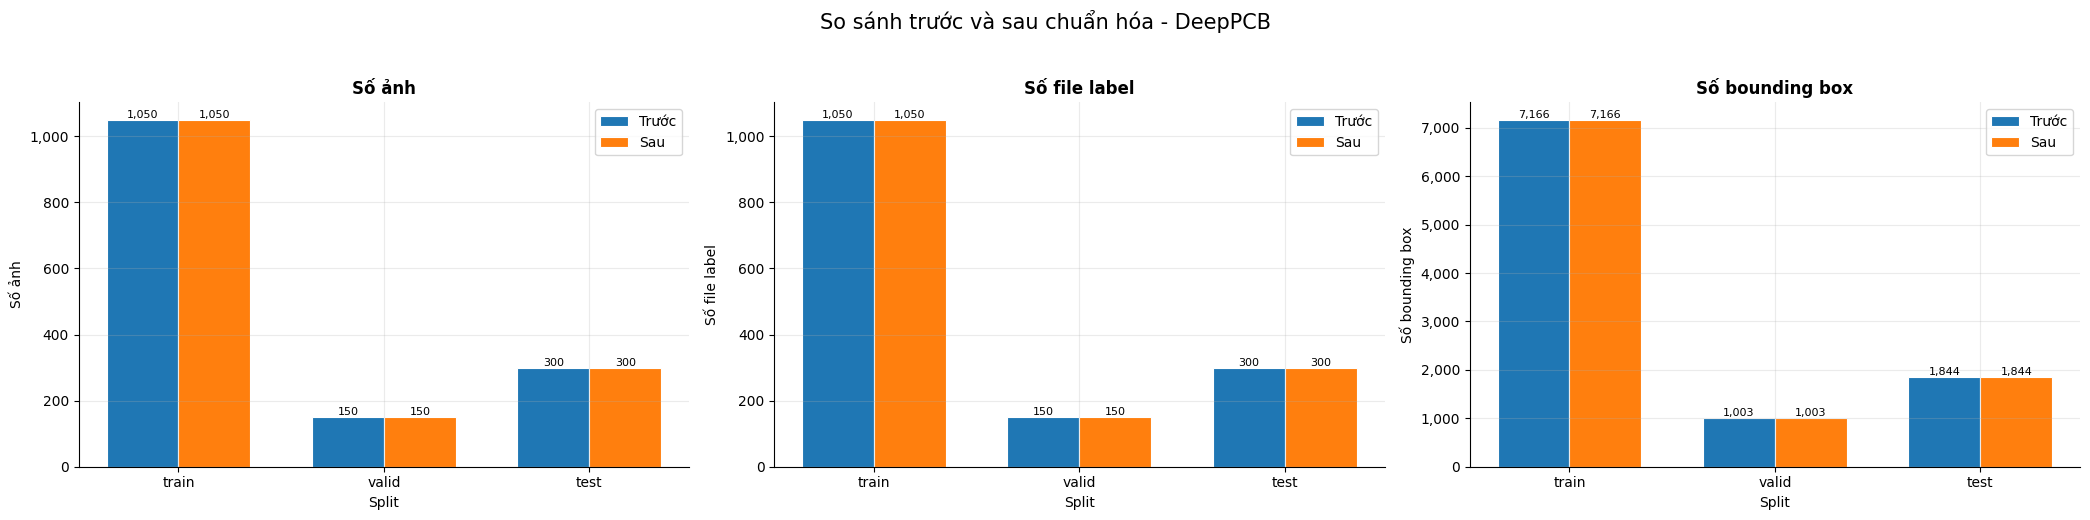

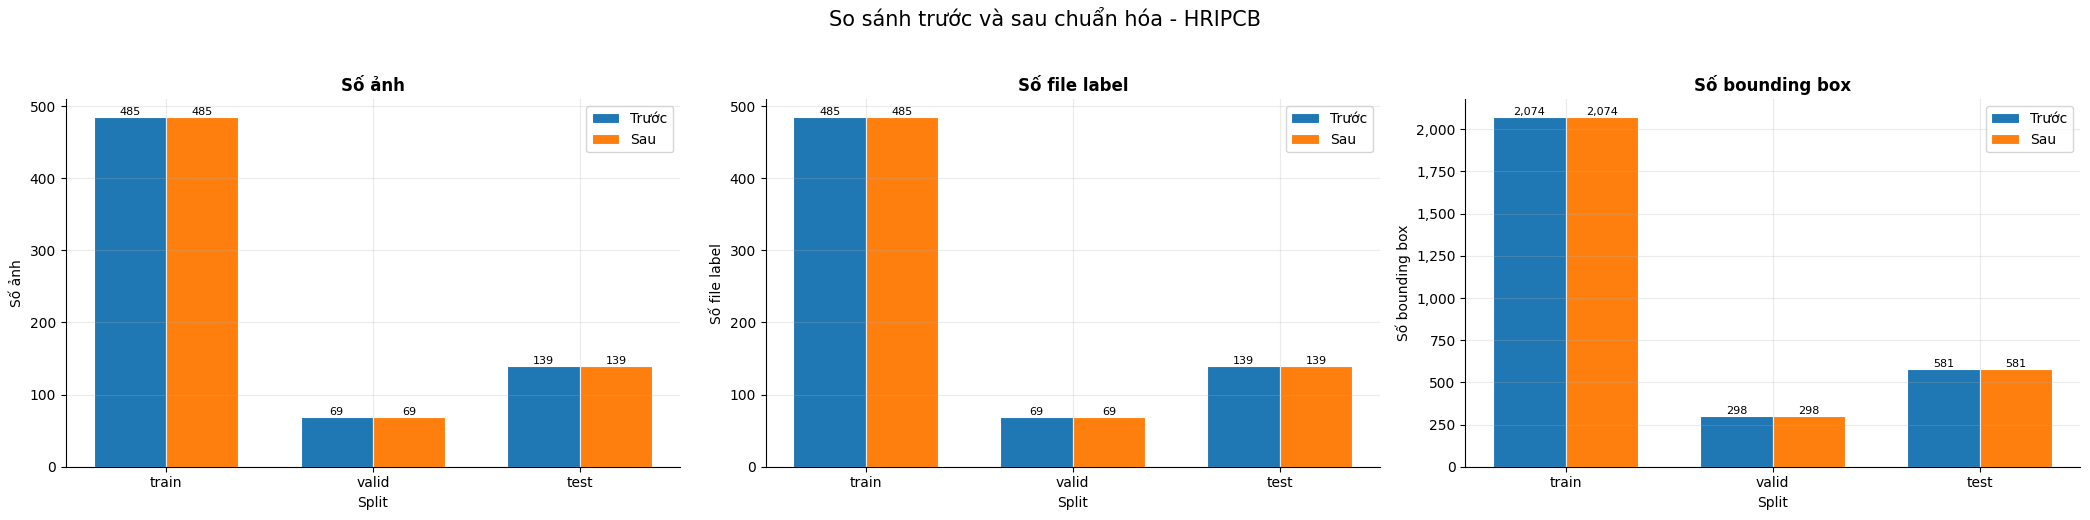

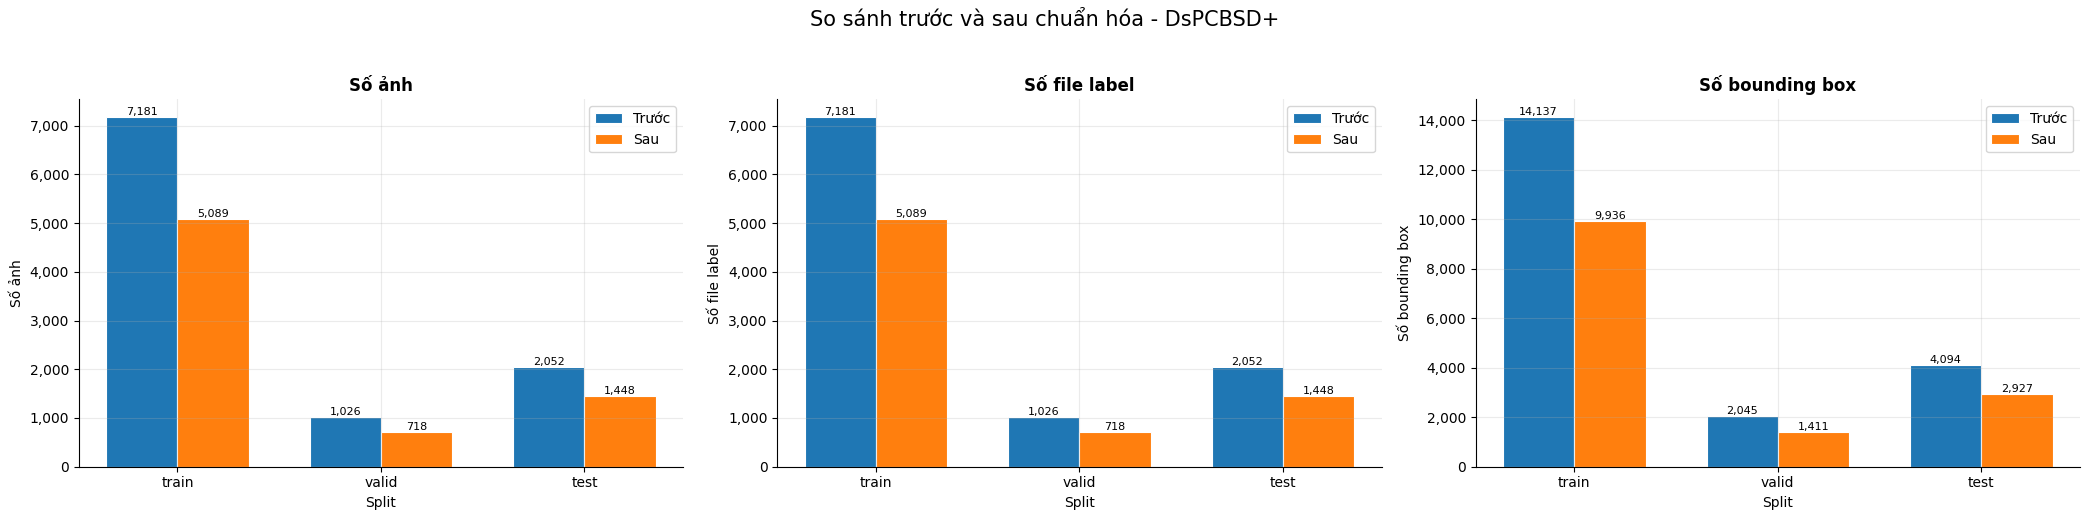

In [9]:
def plot_before_after_metrics(pre_df: pd.DataFrame, reports: dict):
    if pre_df.empty or not reports:
        print("Không đủ dữ liệu để vẽ.")
        return

    metrics = [
        ("images", "images_before", "images_after", "Số ảnh"),
        ("labels", "label_files_before", "label_files_after", "Số file label"),
        ("boxes", "boxes_before", "boxes_after", "Số bounding box"),
    ]

    for dataset_name in pre_df["dataset"].unique():
        pre_ds = pre_df[pre_df["dataset"] == dataset_name].copy()
        post_ds = pd.DataFrame([
            {"split": split, **vals}
            for split, vals in reports[dataset_name]["splits"].items()
        ])
        post_ds["split"] = pd.Categorical(post_ds["split"], categories=SPLIT_ORDER, ordered=True)
        pre_ds["split"] = pd.Categorical(pre_ds["split"], categories=SPLIT_ORDER, ordered=True)

        fig, axes = plt.subplots(1, 3, figsize=(21, 5))
        fig.suptitle(f"So sánh trước và sau chuẩn hóa - {dataset_name}", fontsize=15, y=1.03)

        for ax, (metric_name, pre_col, post_col, title) in zip(axes, metrics):
            pre_series = pre_ds.groupby("split", observed=False)[metric_name].sum().reindex(SPLIT_ORDER).fillna(0)
            post_series = post_ds.groupby("split", observed=False)[post_col].sum().reindex(SPLIT_ORDER).fillna(0)

            x = np.arange(len(SPLIT_ORDER))
            width = 0.35

            before_bars = ax.bar(x - width/2, pre_series.values, width, label="Trước", edgecolor="white", linewidth=0.8)
            after_bars = ax.bar(x + width/2, post_series.values, width, label="Sau", edgecolor="white", linewidth=0.8)

            ax.set_xticks(x)
            ax.set_xticklabels(SPLIT_ORDER)
            ax.set_title(title)
            ax.set_xlabel("Split")
            ax.set_ylabel(title)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
            ax.legend()

            for bar in list(before_bars) + list(after_bars):
                h = bar.get_height()
                if h > 0:
                    ax.annotate(
                        f"{int(h):,}",
                        (bar.get_x() + bar.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=8
                    )

        plt.tight_layout()
        plt.show()

plot_before_after_metrics(pre_df, reports)

## 10. Biểu đồ class trước và sau chuẩn hóa theo từng dataset

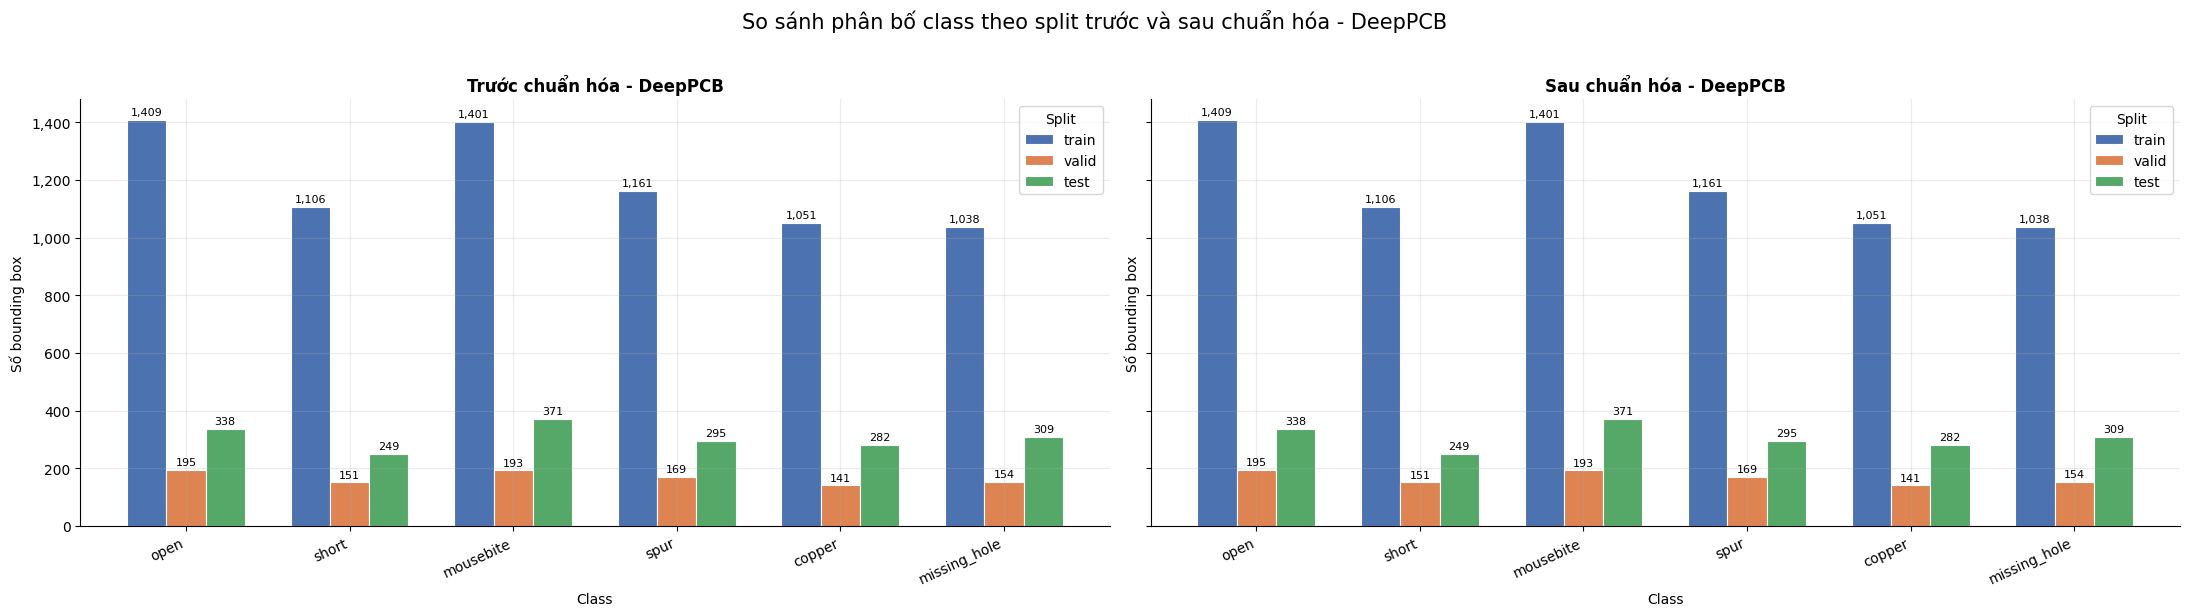

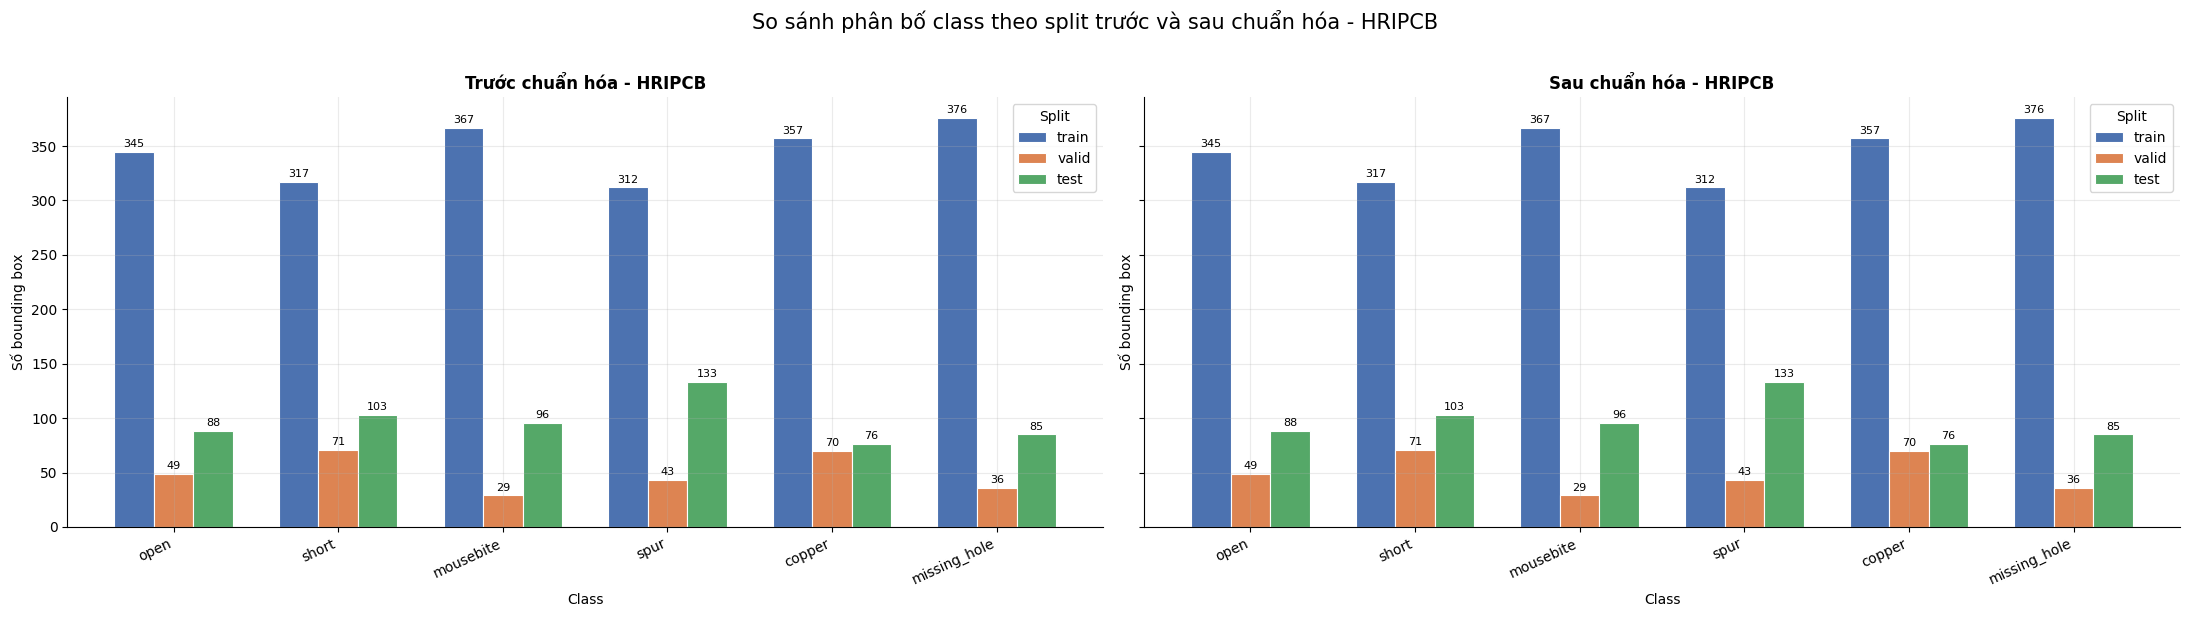

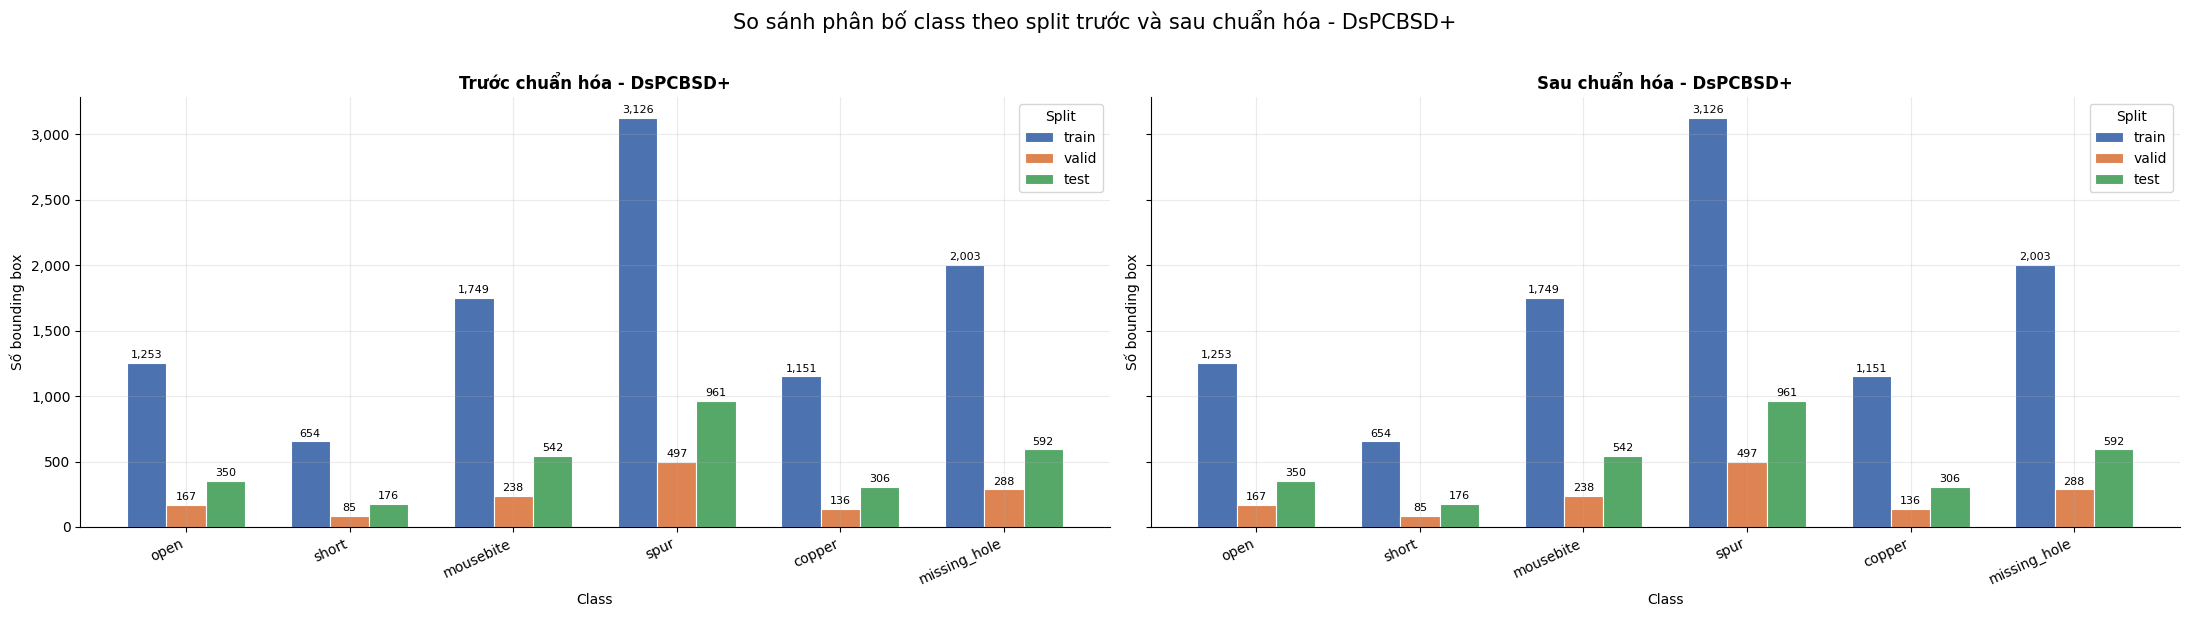

In [10]:
def plot_class_before_after(dataset_inspections, reports):
    for dataset_name in dataset_inspections.keys():
        raw_root = DATASETS[dataset_name]["root"]
        processed_root = PROCESSED_ROOT / dataset_name
        raw_mapping = DATASETS[dataset_name]["mapping"]

        before_counts_by_split = collect_class_counts_by_split(raw_root, raw_mapping)
        after_counts_by_split = collect_class_counts_by_split(processed_root, None)

        fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharey=True)
        fig.suptitle(f"So sánh phân bố class theo split trước và sau chuẩn hóa - {dataset_name}", fontsize=15, y=1.02)

        _plot_class_counts_by_split(
            axes[0],
            before_counts_by_split,
            f"Trước chuẩn hóa - {dataset_name}"
        )
        _plot_class_counts_by_split(
            axes[1],
            after_counts_by_split,
            f"Sau chuẩn hóa - {dataset_name}"
        )

        plt.tight_layout()
        plt.show()

plot_class_before_after(dataset_inspections, reports)


## 11. Xem mẫu ảnh trước và sau chuẩn hóa

Phần này giúp kiểm tra trực quan rằng nhãn sau khi lọc đã đúng và ảnh rỗng đã bị loại bỏ.

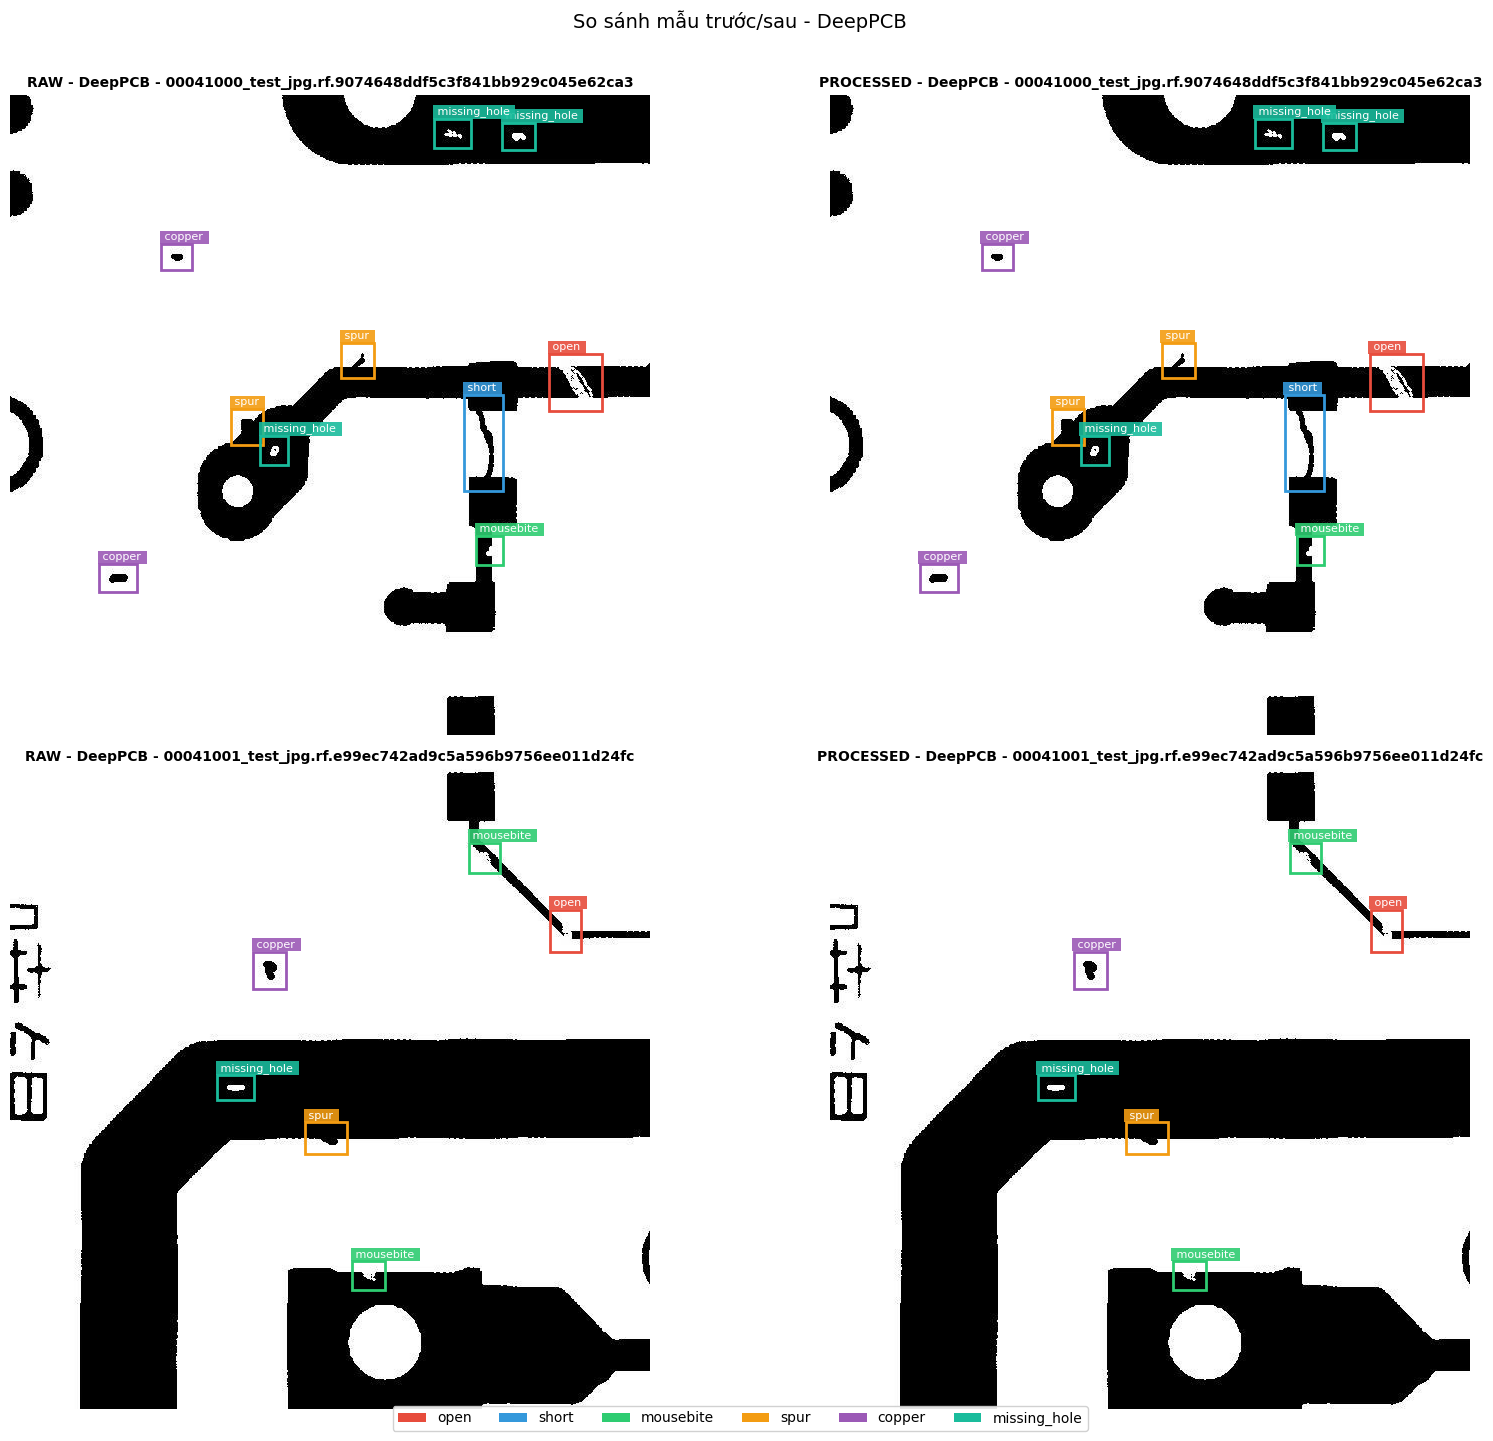

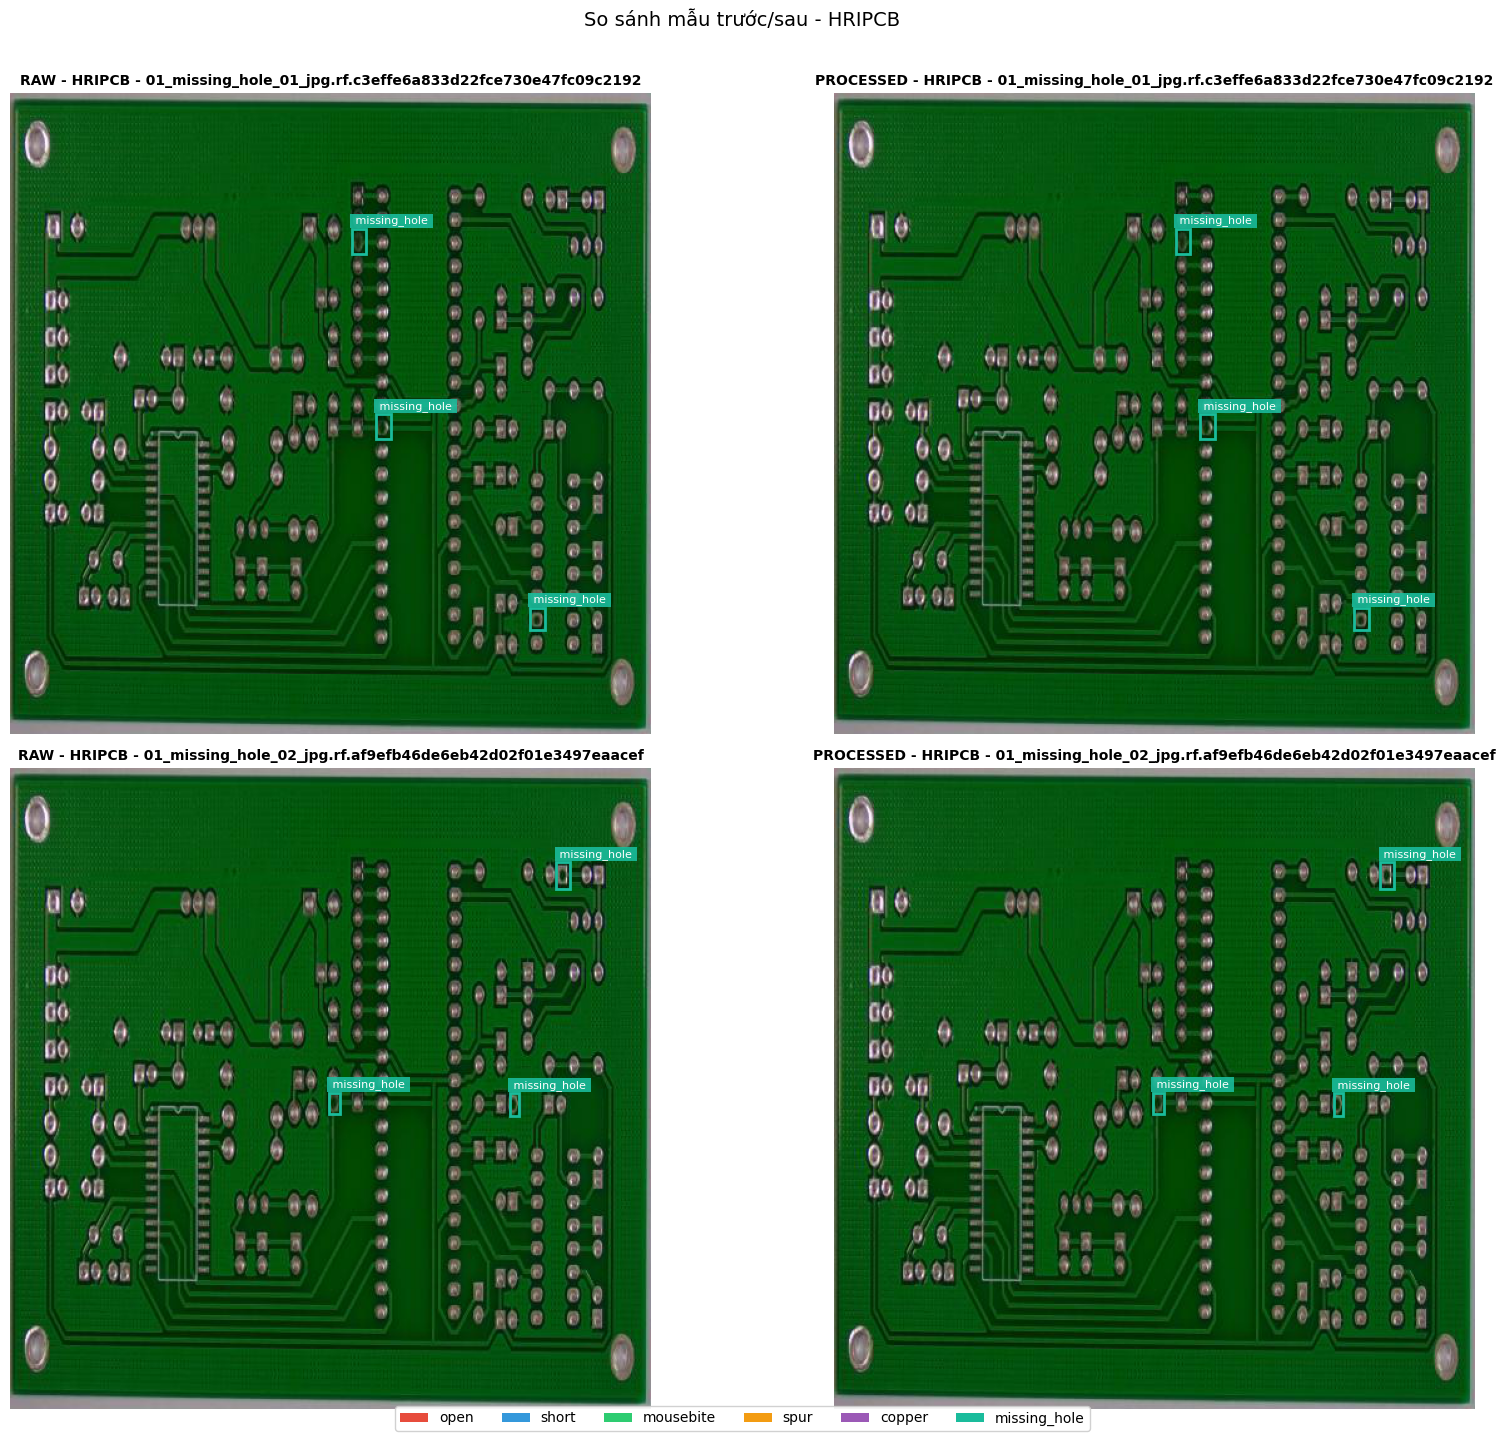

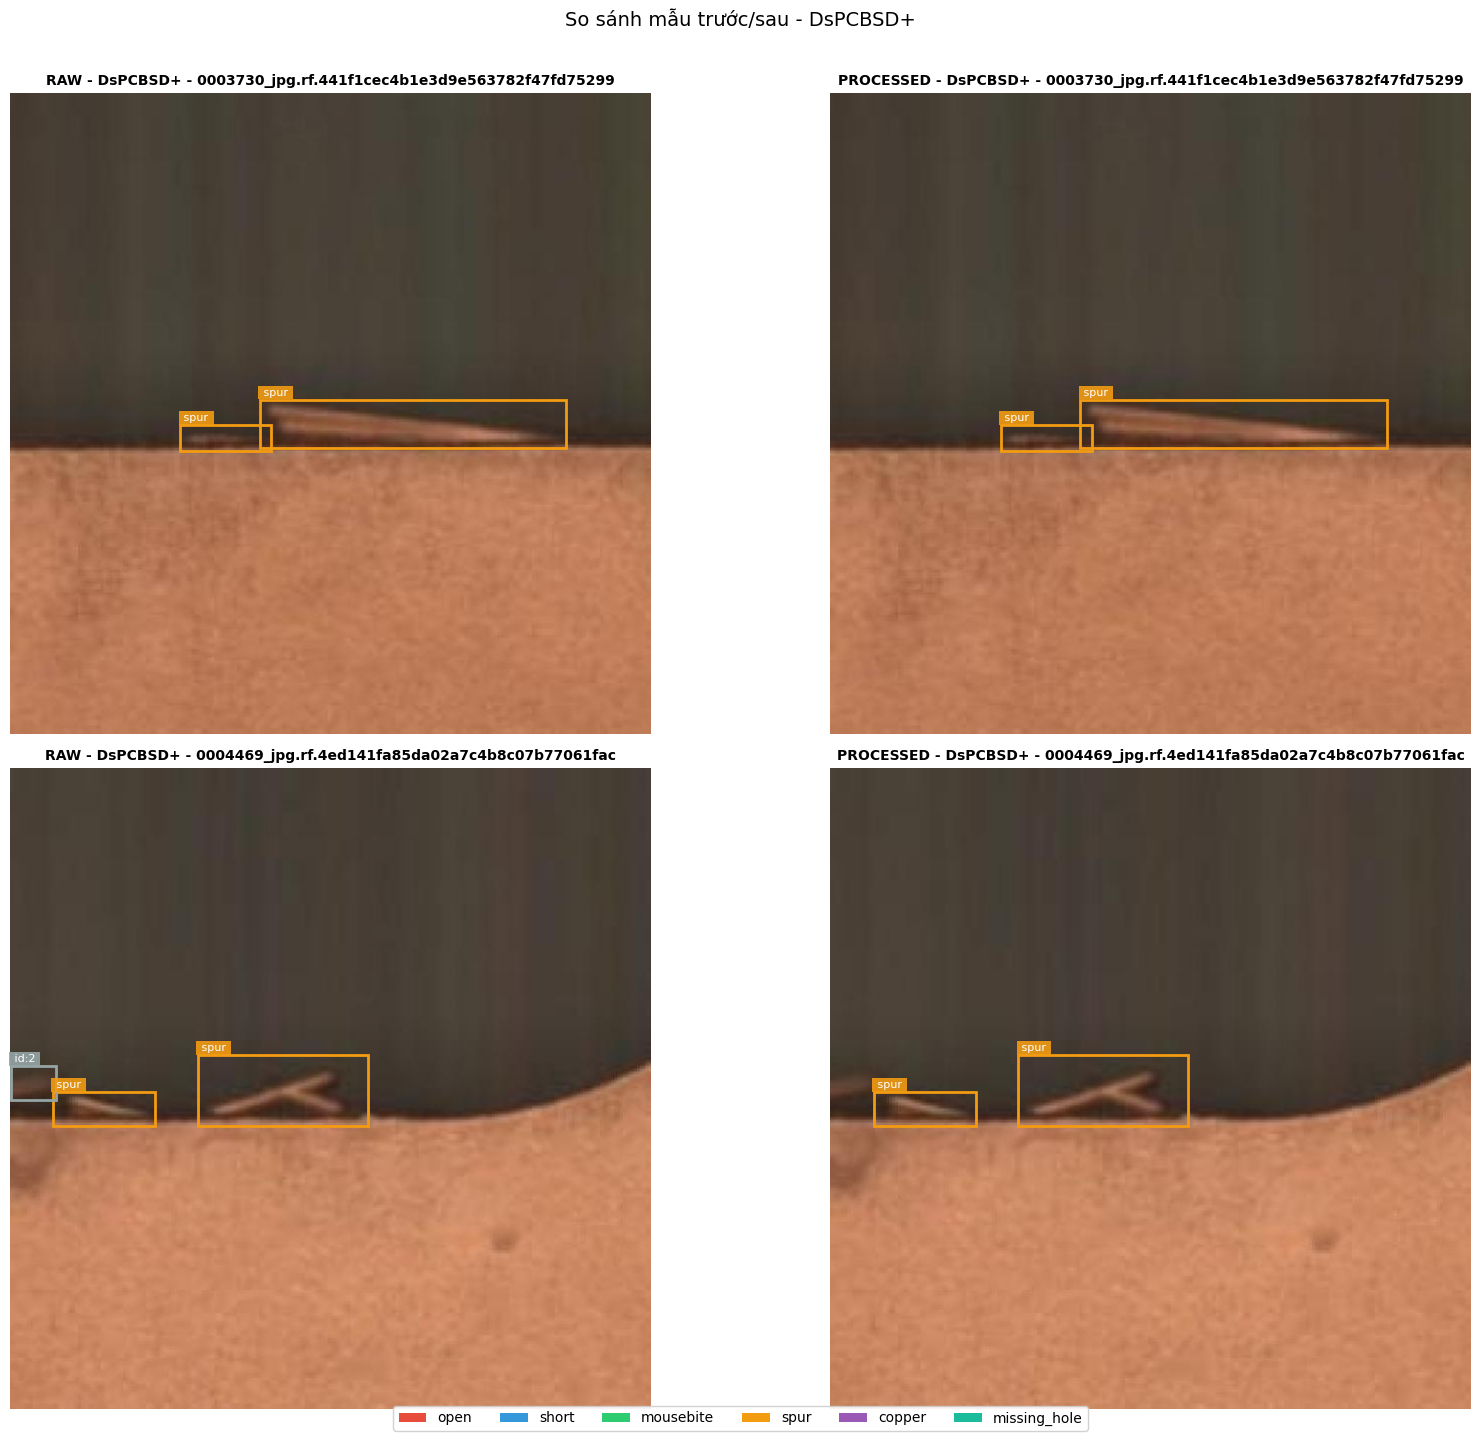

In [11]:
def show_before_after_sample(dataset_name: str, split: str = "train", max_samples: int = 2):
    raw_root = DATASETS[dataset_name]["root"]
    proc_root = PROCESSED_ROOT / dataset_name

    raw_images_dir = raw_root / split / "images"
    raw_labels_dir = raw_root / split / "labels"
    proc_images_dir = proc_root / split / "images"
    proc_labels_dir = proc_root / split / "labels"

    if not raw_labels_dir.exists() or not proc_labels_dir.exists():
        print(f"Missing split for {dataset_name} / {split}")
        return

    sample_labels = list(iter_label_files(raw_labels_dir))[:max_samples]
    if not sample_labels:
        print(f"No label files found for {dataset_name} / {split}")
        return

    raw_id_to_name = RAW_ID_TO_NAME[dataset_name]

    n = len(sample_labels)
    fig, axes = plt.subplots(n, 2, figsize=(18, 7 * n))
    if n == 1:
        axes = [axes]

    legend_patches = [
        mpatches.Patch(facecolor=DEFECT_COLORS.get(cls, DEFECT_COLORS["unknown"]), label=cls)
        for cls in FINAL_CLASS_NAMES
    ]

    for i, raw_label_path in enumerate(sample_labels):
        raw_image_path = find_image_path(raw_images_dir, raw_label_path.stem)
        proc_label_path = proc_labels_dir / raw_label_path.name
        proc_image_path = find_image_path(proc_images_dir, raw_label_path.stem)

        raw_lines = read_yolo_label_file(raw_label_path)
        proc_lines = read_yolo_label_file(proc_label_path) if proc_label_path.exists() else []

        if raw_image_path is not None:
            raw_image = load_image(raw_image_path)
            draw_yolo_boxes(
                axes[i][0], raw_image, raw_lines,
                title=f"RAW - {dataset_name} - {raw_label_path.stem}",
                id_to_name=raw_id_to_name
            )
        else:
            axes[i][0].set_title(f"RAW - {dataset_name} - thiếu ảnh")
            axes[i][0].axis("off")

        if proc_image_path is not None:
            proc_image = load_image(proc_image_path)
            draw_yolo_boxes(
                axes[i][1], proc_image, proc_lines,
                title=f"PROCESSED - {dataset_name} - {raw_label_path.stem}",
                id_to_name=FINAL_ID_TO_NAME
            )
        else:
            axes[i][1].set_title(f"PROCESSED - {dataset_name} - đã bị xóa hoặc rỗng")
            axes[i][1].axis("off")

    fig.legend(
        handles=legend_patches,
        loc="lower center",
        ncol=len(FINAL_CLASS_NAMES),
        framealpha=0.9,
        bbox_to_anchor=(0.5, -0.01)
    )
    fig.suptitle(f"So sánh mẫu trước/sau - {dataset_name}", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

for dataset_name in DATASETS.keys():
    if dataset_name in reports:
        show_before_after_sample(dataset_name, split="train", max_samples=2)

## 12. Tóm tắt output

Sau khi chạy notebook:
- Dataset đã chuẩn hóa nằm trong `data/processed/<dataset_name>/`
- File cấu hình train nằm tại `data/processed/<dataset_name>/data.yaml`
- Bạn có thể trỏ trực tiếp pipeline YOLO vào file `data.yaml` này